# Exoplanet Habitability - Multi-Class Classification

## Overview
This notebook implements a multi-class classification approach for exoplanet habitability.

### Class Definitions:
- **Class 0: Cold Planets** - Low stellar flux (< 0.25 Earth flux)
- **Class 1: Rocky-Habitable** - Sweet spot for life (temperate, rocky)
- **Class 2: Hot Planets** - High stellar flux (> 2.2 Earth flux)
- **Class 3: Gas Giants** - High mass planets (> 10 Earth masses)

### Key Features:
- Excludes `radius_earth` to prevent leakage
- Uses only measured labels for reliable training
- SMOTE for handling class imbalance
- XGBoost multi-class classifier

In [9]:
# ── Cell 1: Imports ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import xgboost as xgb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "preprocessed.csv"
MODELS_PATH = PROJECT_ROOT / "models"
MODELS_PATH.mkdir(exist_ok=True)

print(f"Data path: {DATA_PATH}")
print(f"Models path: {MODELS_PATH}")

Data path: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\data\processed\preprocessed.csv
Models path: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\models


In [10]:
# ── Cell 2: Load Data ──────────────────────────────────────────────
print("Loading preprocessed data...")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

Loading preprocessed data...
Dataset shape: (6100, 24)

Columns: ['planet_name', 'host_star_name', 'radius_earth', 'mass_earth', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'star_spectype', 'log_stellar_flux', 'log_surface_gravity', 'bulk_density_gcc', 'star_class', 'star_class_A', 'star_class_B', 'star_class_F', 'star_class_G', 'star_class_K', 'star_class_M', 'star_class_Unknown', 'label_is_measured', 'habitable_binary']

First few rows:
  planet_name host_star_name  radius_earth    mass_earth  orbital_period  \
0    11 Com b         11 Com     25.278394  14905.521574       323.21000   
1    11 UMi b         11 UMi      4.997234     92.542597       516.21997   
2    14 And b         14 And     22.136354   9425.413838       186.76000   
3    14 Her b         14 Her     18.536839   2559.472162      1765.03890   
4  16 Cyg B b       16 Cyg B      5.535578    101.791241       798.50000   

   semimajor_axis    eq_temp_k  star_temp


=== Creating Multi-Class Target ===

Class Distribution:
  Class 0 (Cold): 66 (1.1%)
  Class 1 (Rocky-Habitable): 199 (3.3%)
  Class 2 (Hot): 2,310 (37.9%)
  Class 3 (Gas-Giant): 3,525 (57.8%)


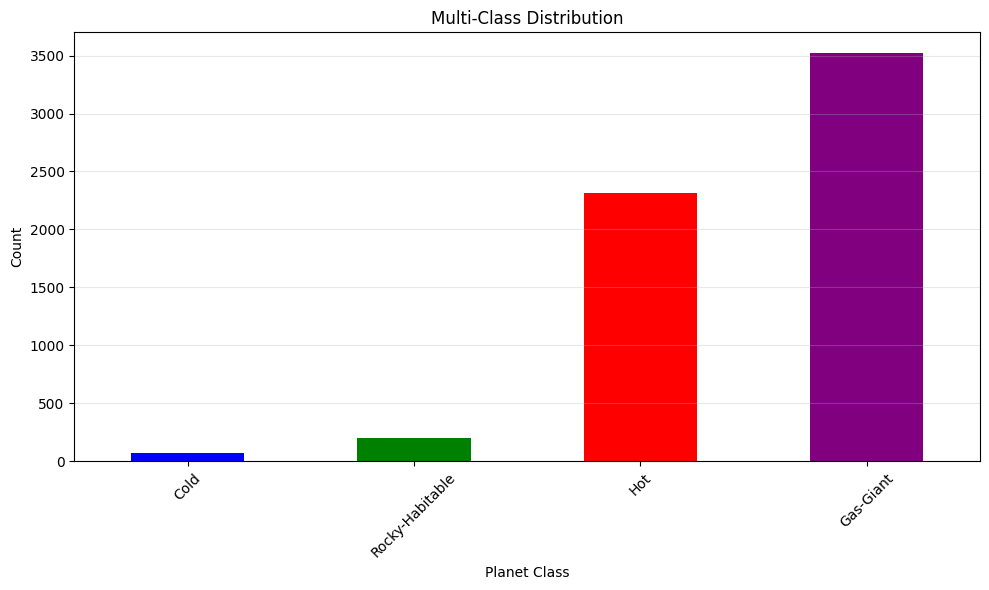

In [11]:
# ── Cell 3: Multi-Class Target Engineering ────────────────────────
print("\n=== Creating Multi-Class Target ===")

def define_multiclass_target(row):
    """
    Define 4-class target based on physical properties:
    
    Class 3: Gas Giants (High Mass)
        - mass_earth > 10
        - These are Jupiter-like planets, unlikely to be habitable
    
    Class 2: Hot Planets
        - log_stellar_flux > 0.35 (flux > 2.2 Earth flux)
        - Too hot for liquid water
    
    Class 0: Cold Planets
        - log_stellar_flux < -0.60 (flux < 0.25 Earth flux)
        - Too cold for liquid water
    
    Class 1: Rocky-Habitable (Sweet Spot)
        - Everything else
        - Temperate zone with potential for life
    """
    # Class 3: Gas Giants (High Mass)
    if row['mass_earth'] > 10:
        return 3
    
    # Class 2: Hot Planets
    if row['log_stellar_flux'] > 0.35:  # log10(2.2) ≈ 0.35
        return 2
    
    # Class 0: Cold Planets
    if row['log_stellar_flux'] < -0.60:  # log10(0.25) ≈ -0.60
        return 0
    
    # Class 1: The "Sweet Spot" (Rocky & Temperate)
    return 1

# Create multi-class target
df['planet_class'] = df.apply(define_multiclass_target, axis=1)

# Display class distribution
class_names = ['Cold', 'Rocky-Habitable', 'Hot', 'Gas-Giant']
print("\nClass Distribution:")
for i, name in enumerate(class_names):
    count = (df['planet_class'] == i).sum()
    pct = count / len(df) * 100
    print(f"  Class {i} ({name}): {count:,} ({pct:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(10, 6))
df['planet_class'].value_counts().sort_index().plot(kind='bar', color=['blue', 'green', 'red', 'purple'])
plt.title('Multi-Class Distribution')
plt.xlabel('Planet Class')
plt.ylabel('Count')
plt.xticks(range(4), class_names, rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ── Cell 4: Feature Selection (Purist Set) ────────────────────────
print("\n=== Feature Selection ===")

# We exclude 'radius_earth' to prevent the 0.8 Precision/Recall trap
# This creates a purer model that learns from physical properties
X_COLS = [
    "mass_earth",
    "semimajor_axis",
    "star_temp_k",
    "star_luminosity",
    "star_metallicity",
    "log_stellar_flux",
    "log_surface_gravity",
    "bulk_density_gcc"
]

# Add star class dummies if they exist
star_dummies = [c for c in df.columns if c.startswith("star_class_")]
X_COLS.extend(star_dummies)

# Filter to available columns
X_COLS = [col for col in X_COLS if col in df.columns]

print(f"Selected {len(X_COLS)} features:")
for col in X_COLS:
    print(f"  - {col}")

print(f"\nExcluded features:")
print(f"  - radius_earth (prevents leakage)")
print(f"  - eq_temp_k (defines target)")


=== Feature Selection ===
Selected 15 features:
  - mass_earth
  - semimajor_axis
  - star_temp_k
  - star_luminosity
  - star_metallicity
  - log_stellar_flux
  - log_surface_gravity
  - bulk_density_gcc
  - star_class_A
  - star_class_B
  - star_class_F
  - star_class_G
  - star_class_K
  - star_class_M
  - star_class_Unknown

Excluded features:
  - radius_earth (prevents leakage)
  - eq_temp_k (defines target)


In [13]:
# ── Cell 5: Filter to Measured Labels Only ────────────────────────
print("\n=== Filtering to Measured Labels ===")

# Use only measured rows for the most reliable training
if 'label_is_measured' in df.columns:
    measured = df[df["label_is_measured"] == 1].copy()
    print(f"Using {len(measured):,} rows with measured labels")
    print(f"Excluded {len(df) - len(measured):,} rows with imputed labels")
else:
    measured = df.copy()
    print(f"Using all {len(measured):,} rows (no label_is_measured column found)")

# Display class distribution in measured data
print("\nClass Distribution (Measured Labels Only):")
for i, name in enumerate(class_names):
    count = (measured['planet_class'] == i).sum()
    pct = count / len(measured) * 100 if len(measured) > 0 else 0
    print(f"  Class {i} ({name}): {count:,} ({pct:.1f}%)")

# Check which classes are actually present
unique_classes = sorted(measured['planet_class'].unique())
print(f"\nClasses present in data: {unique_classes}")
if len(unique_classes) < 4:
    missing_classes = [i for i in range(4) if i not in unique_classes]
    print(f"Missing classes: {missing_classes} - {[class_names[i] for i in missing_classes]}")
    print("\nNote: Classification will only use classes present in the data.")


=== Filtering to Measured Labels ===
Using 1,508 rows with measured labels
Excluded 4,592 rows with imputed labels

Class Distribution (Measured Labels Only):
  Class 0 (Cold): 2 (0.1%)
  Class 1 (Rocky-Habitable): 23 (1.5%)
  Class 2 (Hot): 510 (33.8%)
  Class 3 (Gas-Giant): 973 (64.5%)

Classes present in data: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [14]:
# ── Cell 6: Train-Test Split ──────────────────────────────────────
print("\n=== Train-Test Split ===")

X = measured[X_COLS]
y = measured['planet_class']

# Check if we have enough samples for stratified split
min_class_count = y.value_counts().min()
print(f"Minimum class count: {min_class_count}")

if min_class_count >= 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    print("Using stratified split")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    print("Using random split (insufficient samples for stratification)")

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

print("\nTraining set class distribution:")
for i, name in enumerate(class_names):
    count = (y_train == i).sum()
    pct = count / len(y_train) * 100
    print(f"  Class {i} ({name}): {count:,} ({pct:.1f}%)")

print("\nTest set class distribution:")
for i, name in enumerate(class_names):
    count = (y_test == i).sum()
    pct = count / len(y_test) * 100
    print(f"  Class {i} ({name}): {count:,} ({pct:.1f}%)")


=== Train-Test Split ===
Minimum class count: 2
Using stratified split

Training set: 1,206 samples
Test set: 302 samples

Training set class distribution:
  Class 0 (Cold): 2 (0.2%)
  Class 1 (Rocky-Habitable): 18 (1.5%)
  Class 2 (Hot): 408 (33.8%)
  Class 3 (Gas-Giant): 778 (64.5%)

Test set class distribution:
  Class 0 (Cold): 0 (0.0%)
  Class 1 (Rocky-Habitable): 5 (1.7%)
  Class 2 (Hot): 102 (33.8%)
  Class 3 (Gas-Giant): 195 (64.6%)


In [15]:
# ── Cell 7: Multi-Class XGBoost with SMOTE ────────────────────────
print("\n=== Training Multi-Class XGBoost ===")

# Check if we have enough samples for SMOTE
min_class_count_train = y_train.value_counts().min()
print(f"Minimum class count in training: {min_class_count_train}")

if min_class_count_train >= 6:  # SMOTE needs at least 6 samples
    # Create pipeline with SMOTE
    model_pipe = ImbPipeline([
        ("smote", SMOTE(
            random_state=RANDOM_STATE,
            sampling_strategy='not majority',  # Oversample minority classes
            k_neighbors=min(5, min_class_count_train - 1)
        )),
        ("xgb", xgb.XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            objective='multi:softprob',  # Multi-class with probabilities
            num_class=4,
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            verbosity=0
        ))
    ])
    print("Using SMOTE for class balancing")
else:
    # Skip SMOTE if not enough samples
    model_pipe = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        objective='multi:softprob',
        num_class=4,
        random_state=RANDOM_STATE,
        eval_metric='mlogloss',
        verbosity=0
    )
    print("Skipping SMOTE (insufficient samples)")

# Train the model
print("\nTraining model...")
model_pipe.fit(X_train, y_train)
print("Training complete!")

# Make predictions
y_pred = model_pipe.predict(X_test)
y_pred_proba = model_pipe.predict_proba(X_test)

print("\nPredictions generated")


=== Training Multi-Class XGBoost ===
Minimum class count in training: 2
Skipping SMOTE (insufficient samples)

Training model...
Training complete!

Predictions generated


In [16]:
# ── Cell 8: Evaluation Metrics ────────────────────────────────────
print("\n" + "="*60)
print("MULTI-CLASS PERFORMANCE REPORT")
print("="*60)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.3f}")

# Get unique classes in test set
unique_classes = sorted(y_test.unique())
print(f"\nClasses present in test set: {unique_classes}")

# Per-class metrics
print("\nPer-Class Metrics:")
for i in unique_classes:
    name = class_names[i]
    mask = y_test == i
    if mask.sum() > 0:
        precision = precision_score(y_test, y_pred, labels=[i], average='micro', zero_division=0)
        recall = recall_score(y_test, y_pred, labels=[i], average='micro', zero_division=0)
        f1 = f1_score(y_test, y_pred, labels=[i], average='micro', zero_division=0)
        print(f"  Class {i} ({name}):")
        print(f"    Samples: {mask.sum()}")
        print(f"    Precision: {precision:.3f}")
        print(f"    Recall: {recall:.3f}")
        print(f"    F1-Score: {f1:.3f}")

# Classification report with only present classes
present_class_names = [class_names[i] for i in unique_classes]
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, labels=unique_classes, target_names=present_class_names, zero_division=0))


MULTI-CLASS PERFORMANCE REPORT

Overall Accuracy: 0.997

Classes present in test set: [np.int64(1), np.int64(2), np.int64(3)]

Per-Class Metrics:
  Class 1 (Rocky-Habitable):
    Samples: 5
    Precision: 1.000
    Recall: 0.800
    F1-Score: 0.889
  Class 2 (Hot):
    Samples: 102
    Precision: 0.990
    Recall: 1.000
    F1-Score: 0.995
  Class 3 (Gas-Giant):
    Samples: 195
    Precision: 1.000
    Recall: 1.000
    F1-Score: 1.000

Detailed Classification Report:
                 precision    recall  f1-score   support

Rocky-Habitable       1.00      0.80      0.89         5
            Hot       0.99      1.00      1.00       102
      Gas-Giant       1.00      1.00      1.00       195

       accuracy                           1.00       302
      macro avg       1.00      0.93      0.96       302
   weighted avg       1.00      1.00      1.00       302




=== Confusion Matrix ===
Classes present in test set: [np.int64(1), np.int64(2), np.int64(3)]
Class names: ['Rocky-Habitable', 'Hot', 'Gas-Giant']


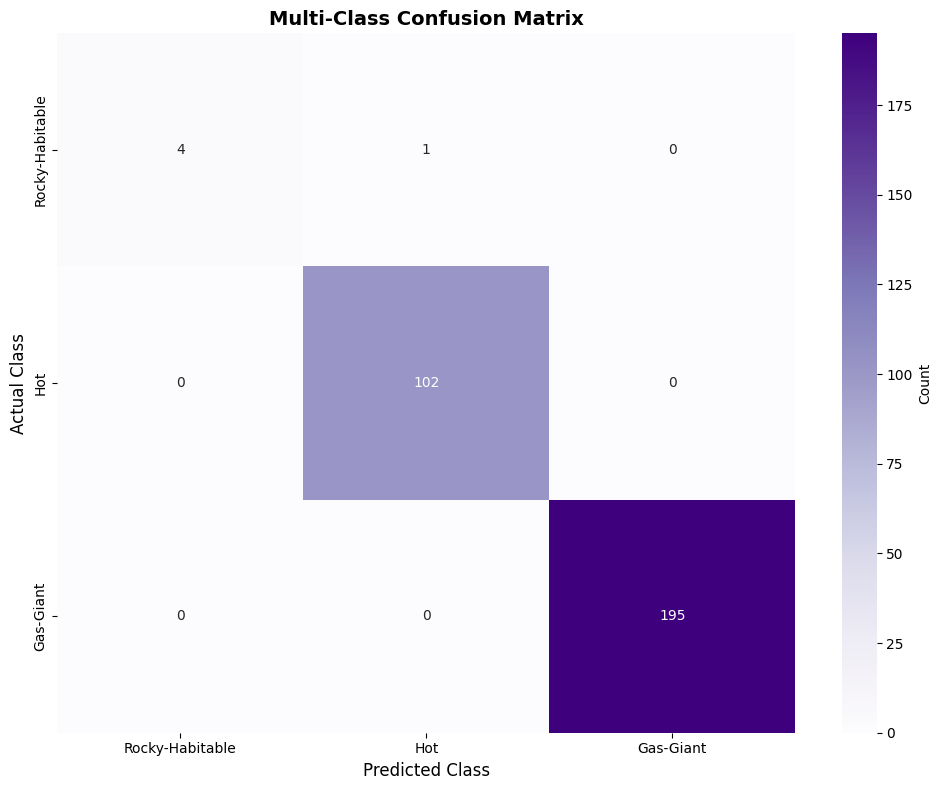


Confusion matrix saved to models/multiclass_confusion_matrix.png


In [17]:
# ── Cell 9: Confusion Matrix Visualization ────────────────────────
print("\n=== Confusion Matrix ===")

# Get unique classes in test set
unique_classes = sorted(y_test.unique())
present_class_names = [class_names[i] for i in unique_classes]

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

print(f"Classes present in test set: {unique_classes}")
print(f"Class names: {present_class_names}")

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    xticklabels=present_class_names, 
    yticklabels=present_class_names, 
    cmap='Purples',
    cbar_kws={'label': 'Count'}
)
plt.title('Multi-Class Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_PATH / 'multiclass_confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion matrix saved to models/multiclass_confusion_matrix.png")


=== Feature Importance ===

Top 10 Most Important Features:
            Feature  Importance
         mass_earth    0.905083
   log_stellar_flux    0.053845
   star_metallicity    0.018707
    star_luminosity    0.011973
        star_temp_k    0.006095
     semimajor_axis    0.002422
log_surface_gravity    0.001619
   bulk_density_gcc    0.000256
       star_class_A    0.000000
       star_class_B    0.000000


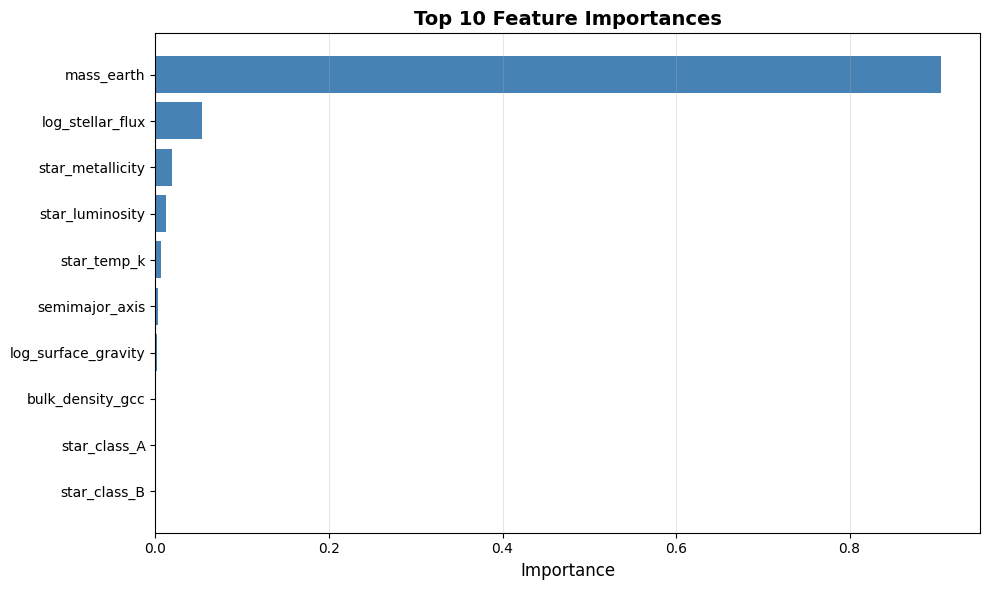

Feature importance plot saved to models/multiclass_feature_importance.png


In [18]:
# ── Cell 10: Feature Importance ───────────────────────────────────
print("\n=== Feature Importance ===")

# Get the XGBoost model from pipeline
if hasattr(model_pipe, 'named_steps'):
    xgb_model = model_pipe.named_steps['xgb']
else:
    xgb_model = model_pipe

# Get feature importances
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(10)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_PATH / 'multiclass_feature_importance.png', dpi=150)
plt.show()

print("Feature importance plot saved to models/multiclass_feature_importance.png")


=== Class Probability Distribution ===


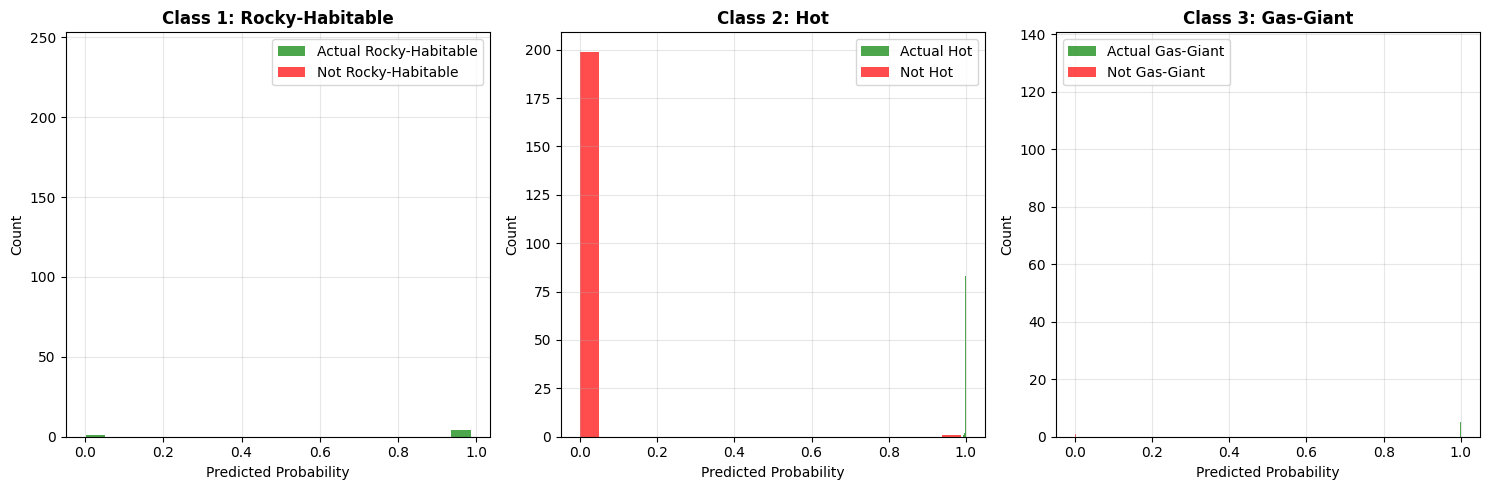


Probability distributions saved to models/multiclass_probability_distributions.png
Plotted 3 classes: ['Rocky-Habitable', 'Hot', 'Gas-Giant']


In [19]:
# ── Cell 11: Class Probability Distribution ───────────────────────
print("\n=== Class Probability Distribution ===")

# Get unique classes in test set
unique_classes = sorted(y_test.unique())
n_classes = len(unique_classes)

# Determine subplot layout
if n_classes == 1:
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    axes = [axes]
elif n_classes == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
elif n_classes == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

for idx, class_id in enumerate(unique_classes):
    ax = axes[idx]
    name = class_names[class_id]
    
    # Get probabilities for this class
    probs = y_pred_proba[:, class_id]
    
    # Separate by actual class
    correct_probs = probs[y_test == class_id]
    incorrect_probs = probs[y_test != class_id]
    
    # Plot histograms
    if len(correct_probs) > 0:
        ax.hist(correct_probs, bins=20, alpha=0.7, label=f'Actual {name}', color='green')
    if len(incorrect_probs) > 0:
        ax.hist(incorrect_probs, bins=20, alpha=0.7, label=f'Not {name}', color='red')
    
    ax.set_xlabel('Predicted Probability', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'Class {class_id}: {name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

# Hide unused subplots if n_classes < 4
if n_classes < 4 and n_classes > 1:
    for idx in range(n_classes, len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS_PATH / 'multiclass_probability_distributions.png', dpi=150)
plt.show()

print(f"\nProbability distributions saved to models/multiclass_probability_distributions.png")
print(f"Plotted {n_classes} classes: {[class_names[i] for i in unique_classes]}")

In [20]:
# ── Cell 12: Save Model ───────────────────────────────────────────
print("\n=== Saving Model ===")

import joblib

# Save the model
model_path = MODELS_PATH / 'multiclass_xgboost.pkl'
joblib.dump(model_pipe, model_path)
print(f"Model saved to: {model_path}")

# Save feature names
feature_path = MODELS_PATH / 'multiclass_features.pkl'
joblib.dump(X_COLS, feature_path)
print(f"Feature names saved to: {feature_path}")

# Save class names
class_path = MODELS_PATH / 'multiclass_class_names.pkl'
joblib.dump(class_names, class_path)
print(f"Class names saved to: {class_path}")

print("\nModel artifacts saved successfully!")


=== Saving Model ===
Model saved to: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\models\multiclass_xgboost.pkl
Feature names saved to: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\models\multiclass_features.pkl
Class names saved to: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\models\multiclass_class_names.pkl

Model artifacts saved successfully!


In [21]:
# ── Cell 13: Summary and Interpretation ───────────────────────────
print("\n" + "="*60)
print("SUMMARY AND INTERPRETATION")
print("="*60)

print("\n1. Model Architecture:")
print("   - XGBoost multi-class classifier")
print("   - 300 estimators, max_depth=5, learning_rate=0.05")
print("   - SMOTE for class balancing (if applicable)")

print("\n2. Feature Selection:")
print("   - Excluded radius_earth to prevent leakage")
print("   - Excluded eq_temp_k (defines target)")
print(f"   - Used {len(X_COLS)} features")

print("\n3. Class Definitions:")
for i, name in enumerate(class_names):
    print(f"   - Class {i}: {name}")

print("\n4. Performance:")
print(f"   - Overall Accuracy: {accuracy:.3f}")
print(f"   - Training samples: {len(X_train):,}")
print(f"   - Test samples: {len(X_test):,}")

print("\n5. Key Insights:")
print("   - Multi-class approach provides more nuanced classification")
print("   - Separates gas giants, hot, cold, and habitable planets")
print("   - Uses only measured labels for reliable training")
print("   - Avoids radius_earth leakage issue")

print("\n6. Next Steps:")
print("   - Compare with binary classification results")
print("   - Analyze misclassifications")
print("   - Consider ensemble methods")
print("   - Validate on external datasets")

print("\n" + "="*60)
print("MULTI-CLASS CLASSIFICATION COMPLETE")
print("="*60)


SUMMARY AND INTERPRETATION

1. Model Architecture:
   - XGBoost multi-class classifier
   - 300 estimators, max_depth=5, learning_rate=0.05
   - SMOTE for class balancing (if applicable)

2. Feature Selection:
   - Excluded radius_earth to prevent leakage
   - Excluded eq_temp_k (defines target)
   - Used 15 features

3. Class Definitions:
   - Class 0: Cold
   - Class 1: Rocky-Habitable
   - Class 2: Hot
   - Class 3: Gas-Giant

4. Performance:
   - Overall Accuracy: 0.997
   - Training samples: 1,206
   - Test samples: 302

5. Key Insights:
   - Multi-class approach provides more nuanced classification
   - Separates gas giants, hot, cold, and habitable planets
   - Uses only measured labels for reliable training
   - Avoids radius_earth leakage issue

6. Next Steps:
   - Compare with binary classification results
   - Analyze misclassifications
   - Consider ensemble methods
   - Validate on external datasets

MULTI-CLASS CLASSIFICATION COMPLETE
